# Keyframe Montage

Loads a rollout MP4 and composites keyframes spaced through it into a SINGLE image — a
stroboscopic overlay. The camera is fixed and the robot/peg sweeps across the scene, so overlaying
keyframes shows the arm at successive positions (left → right) in one frame: you read the task
unfolding at a glance.

Tune three knobs in the last cell and re-run it (the video only loads once):

* **frames between keyframes** — how densely the poses are overlaid,
* **crop** — pixels trimmed off each of the 4 sides,
* **alpha** — opacity of each keyframe.

Video reading + compositing live in `keyframe_utils.py`.

## 1. Imports

In [34]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt


# keyframe_utils.py sits next to this notebook in iros_workshop_analysis/. Make it importable
# whether the kernel starts here, in data_analysis/, or at the repo root; also find the repo root
# (the ancestor that contains runs/) so paths resolve regardless of the kernel's cwd.
def _ensure_on_path():
    d = os.path.abspath(os.getcwd())
    while True:
        for cand in (d, os.path.join(d, "iros_workshop_analysis"),
                     os.path.join(d, "data_analysis", "iros_workshop_analysis")):
            if os.path.isfile(os.path.join(cand, "keyframe_utils.py")):
                if cand not in sys.path:
                    sys.path.insert(0, cand)
                return
        parent = os.path.dirname(d)
        if parent == d:
            return
        d = parent


def _find_root(marker="runs"):
    d = os.path.abspath(os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, marker)):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            return os.path.abspath(os.getcwd())
        d = parent


_ensure_on_path()
PROJECT_ROOT = _find_root()
import importlib
import keyframe_utils as ku
importlib.reload(ku)

<module 'keyframe_utils' from '/home/hunter/generalized_hybrid_vic_action_space/data_analysis/iros_workshop_analysis/keyframe_utils.py'>

## 2. Global parameters

In [35]:
# The rollout video to montage (resolved against the repo root, so cwd doesn't matter).
name = "best_2" #"avg_3"
VIDEO_PATH = os.path.join(
    PROJECT_ROOT,
    f"runs/wandb/pitch_sweep_pitch_sweep/VICES_30/0/videos/no_overlay_splits/{name}.mp4")

# Where images are written: a folder inside the project's plots folder.
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "runs", "pitch_sweep_pitch_sweep", "plots", "iros_keyframe")

# A readable output name from the {group}/{agent}/videos/{split}/{file} path (fallback: file stem).
try:
    _p = os.path.normpath(VIDEO_PATH).split(os.sep)
    NAME = f"{_p[-5]}_agent{_p[-4]}_{os.path.splitext(_p[-1])[0]}"
except Exception:
    NAME = os.path.splitext(os.path.basename(VIDEO_PATH))[0]
print("video:", os.path.relpath(VIDEO_PATH, PROJECT_ROOT))
print("name :", NAME)

video: runs/wandb/pitch_sweep_pitch_sweep/VICES_30/0/videos/no_overlay_splits/best_2.mp4
name : VICES_30_agent0_best_2


## 3. Load video

In [36]:
# Read every frame once (this is the slow part). BACKGROUND is the per-pixel median = the static
# scene, used by the "foreground" montage mode; precomputed here so re-running the montage is instant.
FRAMES = ku.load_video(VIDEO_PATH)
BACKGROUND = np.median(FRAMES.astype(float), axis=0)
print(f"loaded {len(FRAMES)} frames, {FRAMES.shape[2]}x{FRAMES.shape[1]} (WxH)")

loaded 75 frames, 552x712 (WxH)


## 4. Keyframe montage

8 keyframes @ [10, 19, 27, 36, 44, 53, 61, 70]
final image size: 412 x 312 px (W x H)
saved /home/hunter/generalized_hybrid_vic_action_space/runs/pitch_sweep_pitch_sweep/plots/iros_keyframe/surface_task_keypoint_sweep.svg


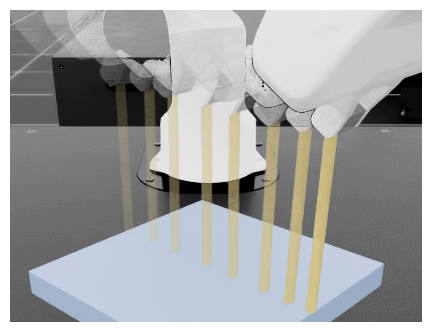

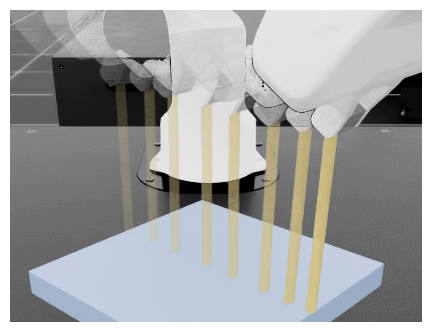

In [44]:
import importlib; importlib.reload(ku)  # hot-reload keyframe_utils (edits apply without re-loading the video)

# --- knobs: change any of these and re-run THIS cell ---
NUM_KEYFRAMES = 8                      # how many keyframe poses to overlay
START_FRAME = 10                       # first frame to use (skip startup artifacts)
END_FRAME = 70 #75                      # last frame to use (None = end); set start+end to montage a middle chunk
CROP_LEFT = 80
CROP_RIGHT = 60
CROP_TOP = 75
CROP_BOTTOM = 325   # pixels trimmed off each side
ALPHA = 0.7                            # opacity of each keyframe (0-1)
ALPHA_START = 0.25                     # opacity FLOOR for the first pose (ramps up to ALPHA_END);
ALPHA_END = 0.95                        #   set ALPHA_START=None to use the flat ALPHA instead
MODE = "foreground"                    # "foreground" = each pose over the static scene (see all poses);
                                       # "over" = plain alpha-over (a motion trail, last pose solid)

img, idx = ku.keyframe_montage(
    FRAMES, num_keyframes=NUM_KEYFRAMES, start=START_FRAME, end=END_FRAME,
    crop=(CROP_LEFT, CROP_RIGHT, CROP_TOP, CROP_BOTTOM),
    alpha=ALPHA, alpha_start=ALPHA_START, alpha_end=ALPHA_END, mode=MODE, background=BACKGROUND)
print(f"{len(idx)} keyframes @ {idx}")
print(f"final image size: {img.shape[1]} x {img.shape[0]} px (W x H)")

# Output file name (without .png) -- change this to save under a different name.
SAVE_NAME = f"surface_task_keypoint_sweep"

# Save the raw montage (no border) into the plots folder, then show it inline (no border).
ku.save_image(img, OUTPUT_DIR, SAVE_NAME)
ku.show_image(img)

## 5. First-frame crop previews

image size: 132 x 192 px (W x H)
saved /home/hunter/generalized_hybrid_vic_action_space/runs/pitch_sweep_pitch_sweep/plots/iros_keyframe/sim_0-deg_grasp.svg


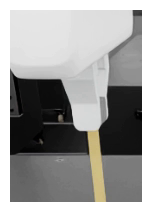

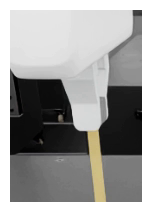

In [38]:
import importlib; importlib.reload(ku)  # hot-reload keyframe_utils

# Preview 1: first frame of a video (give the path from the base directory), cropped per side.
VIDEO = os.path.join(
    PROJECT_ROOT,
    "runs/wandb/pitch_sweep_pitch_sweep/VICES_0/0/videos/no_overlay_splits/worst_1.mp4")
CROP_LEFT = 50
CROP_RIGHT = 370
CROP_TOP = 50
CROP_BOTTOM = 470

frame = ku.crop_frame(ku.load_frame(VIDEO), CROP_LEFT, CROP_RIGHT, CROP_TOP, CROP_BOTTOM)
print(f"image size: {frame.shape[1]} x {frame.shape[0]} px (W x H)")
# Output file name (without .png) -- change this to save under a different name.
SAVE_NAME = "sim_0-deg_grasp" #ku.name_from_path(VIDEO) + "_frame0"

# Save the cropped first frame (no border) into the plots folder, then show it (no border).
ku.save_image(frame, OUTPUT_DIR, SAVE_NAME)
ku.show_image(frame)

image size: 132 x 192 px (W x H)
saved /home/hunter/generalized_hybrid_vic_action_space/runs/pitch_sweep_pitch_sweep/plots/iros_keyframe/sim_15-deg_grasp.svg


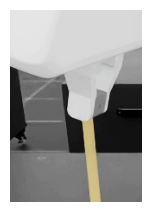

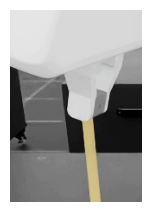

In [39]:
import importlib; importlib.reload(ku)  # hot-reload keyframe_utils

# Preview 2: first frame of a video (give the path from the base directory), cropped per side.
VIDEO = os.path.join(
    PROJECT_ROOT,
    "runs/wandb/pitch_sweep_pitch_sweep/VICES_15/1/videos/no_overlay_splits/avg_2.mp4")
CROP_LEFT = 70
CROP_RIGHT = 350
CROP_TOP = 50
CROP_BOTTOM = 470

frame = ku.crop_frame(ku.load_frame(VIDEO), CROP_LEFT, CROP_RIGHT, CROP_TOP, CROP_BOTTOM)
print(f"image size: {frame.shape[1]} x {frame.shape[0]} px (W x H)")
# Output file name (without .png) -- change this to save under a different name.
SAVE_NAME = "sim_15-deg_grasp" #ku.name_from_path(VIDEO) + "_frame0"

# Save the cropped first frame (no border) into the plots folder, then show it (no border).
ku.save_image(frame, OUTPUT_DIR, SAVE_NAME)
ku.show_image(frame)

image size: 132 x 192 px (W x H)
saved /home/hunter/generalized_hybrid_vic_action_space/runs/pitch_sweep_pitch_sweep/plots/iros_keyframe/sim_30-deg_grasp.svg


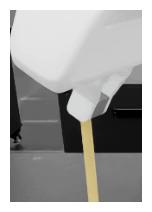

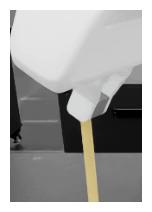

In [40]:
import importlib; importlib.reload(ku)  # hot-reload keyframe_utils

# Preview 3: first frame of a video (give the path from the base directory), cropped per side.
VIDEO = os.path.join(
    PROJECT_ROOT,
    "runs/wandb/pitch_sweep_pitch_sweep/VICES_30/0/videos/no_overlay_splits/avg_0.mp4")
CROP_LEFT = 70
CROP_RIGHT = 350
CROP_TOP = 50
CROP_BOTTOM = 470

frame = ku.crop_frame(ku.load_frame(VIDEO), CROP_LEFT, CROP_RIGHT, CROP_TOP, CROP_BOTTOM)
print(f"image size: {frame.shape[1]} x {frame.shape[0]} px (W x H)")
# Output file name (without .png) -- change this to save under a different name.
SAVE_NAME = "sim_30-deg_grasp" #ku.name_from_path(VIDEO) + "_frame0"

# Save the cropped first frame (no border) into the plots folder, then show it (no border).
ku.save_image(frame, OUTPUT_DIR, SAVE_NAME)
ku.show_image(frame)

image size: 132 x 192 px (W x H)
saved /home/hunter/generalized_hybrid_vic_action_space/runs/pitch_sweep_pitch_sweep/plots/iros_keyframe/sim_45-deg_grasp.svg


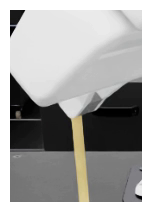

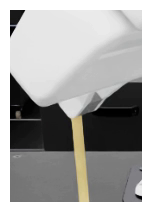

In [41]:
import importlib; importlib.reload(ku)  # hot-reload keyframe_utils

# Preview 4: first frame of a video (give the path from the base directory), cropped per side.
VIDEO = os.path.join(
    PROJECT_ROOT,
    "runs/wandb/pitch_sweep_pitch_sweep/VICES_45/0/videos/no_overlay_splits/best_0.mp4")
CROP_LEFT = 90
CROP_RIGHT = 330
CROP_TOP = 50
CROP_BOTTOM = 470

frame = ku.crop_frame(ku.load_frame(VIDEO), CROP_LEFT, CROP_RIGHT, CROP_TOP, CROP_BOTTOM)
print(f"image size: {frame.shape[1]} x {frame.shape[0]} px (W x H)")
# Output file name (without .png) -- change this to save under a different name.
SAVE_NAME = "sim_45-deg_grasp" #ku.name_from_path(VIDEO) + "_frame0"

# Save the cropped first frame (no border) into the plots folder, then show it (no border).
ku.save_image(frame, OUTPUT_DIR, SAVE_NAME)
ku.show_image(frame)